# Datenaufbereitung: Global Organized Crime Index
**Projekt 3 – Lede**

Dieses Notebook dokumentiert, wie die Rohdaten aus `global_oc_index.xlsx` (Global Organized Crime Index, GI-TOC) aufbereitet werden für die interaktive Weltkarte des Projekts.

**Quelle:** [Global Organized Crime Index](https://ocindex.net) – Global Initiative Against Transnational Organized Crime (GI-TOC). Der Datensatz bewertet 193 UNO-Mitgliedstaaten für die Jahre 2021, 2023 und 2025 entlang mehrerer Kriminalitätsmärkte, u.a. eigens für den Kokainhandel ("Cocaine trade").

**Ziel dieses Notebooks:**
1. Die drei Jahres-Tabellen laden und Struktur prüfen
2. Die Spalten `Criminality avg.` und `Cocaine trade` pro Land und Jahr extrahieren
3. Stichprobenartig auf Plausibilität prüfen (Beispiel Schweiz)
4. Das Ergebnis als JSON exportieren, das die interaktive Karte (D3.js) einliest

## 1. Rohdaten laden


In [1]:
import pandas as pd

xls = pd.ExcelFile("global_oc_index.xlsx")
xls.sheet_names

['2025_Global_OC_Index', '2025_dataset', '2023_dataset', '2021_dataset']

Vier Blätter: ein Deckblatt (`2025_Global_OC_Index`) sowie je eine Datentabelle pro Erhebungsjahr. Ich lade die drei Jahres-Tabellen einzeln.

In [2]:
df_2021 = pd.read_excel(xls, sheet_name="2021_dataset")
df_2023 = pd.read_excel(xls, sheet_name="2023_dataset")
df_2025 = pd.read_excel(xls, sheet_name="2025_dataset")

df_2025.head()

,Continent,Region,Country,Criminality avg.,Criminal markets avg.,Human trafficking,Human smuggling,Extortion and protection racketeering,Arms trafficking,Trade in counterfeit goods,...,International cooperation,National policies and laws,Judicial system and detention,Law enforcement,Territorial integrity,Anti-money laundering,Economic regulatory capacity,Victim and witness support,Prevention,Non-state actors
0,Africa,Central Africa,Angola,5.62,5.33,6.0,5.0,2.5,6.0,5.0,...,5.0,5.0,3.0,4.0,5.5,4.5,4.5,3.5,4.0,3.0
1,Africa,Central Africa,Burundi,4.73,4.67,8.5,5.5,5.5,7.5,6.5,...,2.5,3.0,2.0,1.5,3.0,2.5,2.0,1.5,3.0,2.5
2,Africa,Central Africa,Cameroon,6.18,6.27,6.5,5.5,7.0,7.5,7.5,...,5.5,4.5,2.5,3.5,2.0,3.5,2.5,2.5,3.0,4.0
3,Africa,Central Africa,Central African Republic,7.03,5.97,8.0,5.5,7.0,9.0,7.0,...,3.5,2.5,1.5,2.0,2.0,2.0,1.5,2.0,2.0,2.5
4,Africa,Central Africa,Chad,6.00,5.40,7.5,8.0,6.5,9.0,6.0,...,4.5,3.0,2.0,2.5,3.0,1.5,2.0,1.5,1.5,2.0


## 2. Fehler in den Rohdaten
Beim Vergleich der Spaltennamen fällt auf, dass die Spalte im 2021-Sheet **`Criminality avg,`** heisst (mit Komma statt Punkt am Ende) Tippfehler? 

In [3]:
for year, df in [("2021", df_2021), ("2023", df_2023), ("2025", df_2025)]:
    crim_cols = [c for c in df.columns if "criminality avg" in c.lower()]
    print(year, "->", crim_cols)

2021 -> ['Criminality avg,']
2023 -> ['Criminality avg.']
2025 -> ['Criminality avg.']


## 3. Relevante Spalten auswählen
`Country`, `Continent`, `Criminality avg.` (bzw. die Variante mit Komma) und `Cocaine trade`. 

In [4]:
def select_year(df, year):
    cols = {c: c.strip().rstrip(",.") for c in df.columns}
    df = df.rename(columns=cols)
    out = df[["Continent", "Country", "Criminality avg", "Cocaine trade"]].copy()
    out["year"] = year
    out = out.rename(columns={"Criminality avg": "criminality", "Cocaine trade": "cocaine"})
    return out

long_df = pd.concat([
    select_year(df_2021, "2021"),
    select_year(df_2023, "2023"),
    select_year(df_2025, "2025"),
], ignore_index=True)

long_df = long_df.dropna(subset=["Country"])
long_df.head()

,Continent,Country,criminality,cocaine,year
0,Africa,Angola,5.29,6.0,2021
1,Africa,Burundi,4.51,2.5,2021
2,Africa,Cameroon,6.31,3.5,2021
3,Africa,Central African Republic,7.04,1.5,2021
4,Africa,Chad,5.86,4.5,2021


### 3b. Ländernamen bereinigen
Beim Abgleich mit der Kartengeometrie (nächster Schritt, D3) ist aufgefallen: derselbe Komma/Punkt-Fehler wie bei "Criminality avg," steckt auch in einzelnen Ländernamen. Im 2023-Sheet steht z.B. `Congo, Dem, Rep,` statt `Congo, Dem. Rep.` — Kommas statt Punkten nach Abkürzungen wie "Dem", "Rep" oder "St". Das spaltet dieselben Länder fälschlicherweise in zwei Einträge auf. Zusätzlich gibt es eine Gross-/Kleinschreibungs-Abweichung: "Eswatini" (2021) vs. "eSwatini" (2023/2025).

Beides reparieren wir jetzt, bevor wir weiterrechnen.

In [5]:
import re

def fix_country_name(name):
    name = re.sub(r"\b(Dem|Rep|St)\s*,", r"\1.", name)
    name = name.replace("eSwatini", "Eswatini")
    return name

long_df["Country"] = long_df["Country"].apply(fix_country_name)

# Kontrolle: sind die Duplikate weg?
sorted(c for c in long_df["Country"].unique() if "Dem" in c or "Rep." in c or "watini" in c)

['Congo, Dem. Rep.', 'Congo, Rep.', 'Eswatini', 'Korea, Rep.']

## 4. Stichprobe: Schweiz


In [6]:
switzerland = long_df[long_df["Country"] == "Switzerland"].sort_values("year")
switzerland

,Continent,Country,criminality,cocaine,year
177,Europe,Switzerland,4.34,5.5,2021
370,Europe,Switzerland,4.87,6.0,2023
563,Europe,Switzerland,4.65,6.5,2025


Der Cocaine-trade-Wert steigt über die drei Erhebungen kontinuierlich (5.5 → 6.0 → 6.5), während der allgemeine Kriminalitätswert deutlich tiefer bleibt und stagniert. 

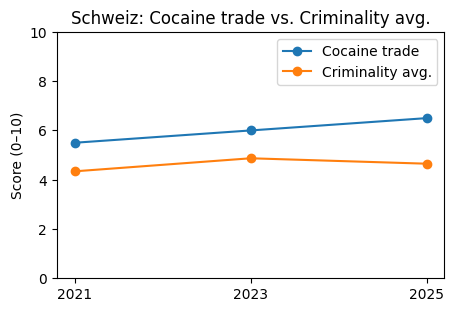

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(switzerland["year"], switzerland["cocaine"], marker="o", label="Cocaine trade")
ax.plot(switzerland["year"], switzerland["criminality"], marker="o", label="Criminality avg.")
ax.set_ylim(0, 10)
ax.set_ylabel("Score (0–10)")
ax.set_title("Schweiz: Cocaine trade vs. Criminality avg.")
ax.legend()
plt.show()

## 5. Plausibilitätscheck: Länderanzahl
Die Dokumentation des Index spricht von 193 UNO-Mitgliedstaaten. In unseren Daten tauchen aber mehr Namen auf...

In [8]:
per_year_counts = long_df.groupby("year")["Country"].nunique()
print(per_year_counts)

all_countries = set(long_df["Country"])
only_in_one_year = [
    c for c in all_countries
    if long_df[long_df["Country"] == c]["year"].nunique() < 3
]
print(f"\n{len(only_in_one_year)} Länder kommen nicht in allen drei Jahren vor, z.B.:")
only_in_one_year[:15]

year
2021    193
2023    193
2025    193
Name: Country, dtype: int64

0 Länder kommen nicht in allen drei Jahren vor, z.B.:


[]

Nicht jedes Land wurde in jedem Jahr erhoben (z.B. neu aufgenommene oder umbenannte Staaten). Für die Karte bedeutet das: manche Länder haben Lücken in einzelnen Jahren...

## 6. Export für die interaktive Karte
pro Land ein Eintrag mit den Werten je Jahr.

In [9]:
import json

result = {}
for _, row in long_df.iterrows():
    entry = result.setdefault(
        row["Country"], {"continent": row["Continent"], "criminality": {}, "cocaine": {}}
    )
    entry["criminality"][row["year"]] = row["criminality"]
    entry["cocaine"][row["year"]] = row["cocaine"]

with open("data/oc_index.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"{len(result)} Länder geschrieben nach data/oc_index.json")
result["Switzerland"]

193 Länder geschrieben nach data/oc_index.json


{'continent': 'Europe',
 'criminality': {'2021': 4.34, '2023': 4.87, '2025': 4.65},
 'cocaine': {'2021': 5.5, '2023': 6.0, '2025': 6.5}}

## Zusammenfassung
- Quelle: `global_oc_index.xlsx` (Global Organized Crime Index, GI-TOC), Blätter `2021_dataset`, `2023_dataset`, `2025_dataset`
- Extrahiert: `Criminality avg.` und `Cocaine trade` pro Land und Jahr
- Eigenheit dokumentiert: abweichender Spaltenname im 2021-Sheet (`Criminality avg,`)
- Plausibilisiert: Stichprobe Schweiz, Länderanzahl pro Jahr geprüft
- Output: `data/oc_index.json` — wird von der interaktiven Weltkarte (D3.js, Schritt 2) eingelesen

**Nächster Schritt:** Kartengrundgerüst mit D3 aufbauen und die Ländernamen aus diesem Datensatz mit der Kartengeometrie abgleichen....